In [ ]:
# import duckdb
# import glob
# import os

# con = duckdb.connect()
# con.execute("INSTALL sqlite; LOAD sqlite;")
# con.execute("ATTACH 'medical_data.db' AS sqlite_db (TYPE SQLITE);")

# for csv_file in glob.glob("../synthea/output/csv/*.csv"):
#     table_name = os.path.splitext(os.path.basename(csv_file))[0]
#     print(f"Importing {table_name}...")
#     con.execute(f"CREATE TABLE sqlite_db.{table_name} AS SELECT * FROM read_csv_auto('{csv_file}');")

# print("Done!")

In [ ]:
import pandas as pd
import numpy as np
from SQL_query import SQLQuery
SQL = SQLQuery("medical_data.db") 
query = """
WITH LATEST_PREGNANCY AS (
    SELECT
        PATIENT,
        MAX(DATE(SUBSTR(START, 1, 10))) AS PREGNANCY_START,
        DATE(MAX(SUBSTR(START, 1, 10)), '+270 days') AS EST_DELIVERY_DATE
    FROM encounters
    WHERE DESCRIPTION = 'Prenatal initial visit (regime/therapy)'
    GROUP BY PATIENT
),
LATEST_PREG_DIA AS (
    SELECT
        o.PATIENT,
        MAX(DATE(SUBSTR(o.DATE, 1, 10))) AS OBSERVATION_DATE,
        MAX(CASE WHEN o.DESCRIPTION = 'Diastolic Blood Pressure' THEN o.VALUE END) AS Diastolic_Blood_Pressure
    FROM observations as o
    INNER JOIN LATEST_PREGNANCY as lp ON o.PATIENT = lp.PATIENT
    WHERE o.DESCRIPTION = 'Diastolic Blood Pressure' AND DATE(SUBSTR(o.DATE, 1, 10)) <= lp.EST_DELIVERY_DATE
    GROUP BY o.PATIENT
),
LATEST_PREG_SYS AS (
    SELECT
        o.PATIENT,
        MAX(DATE(SUBSTR(o.DATE, 1, 10))) AS OBSERVATION_DATE,
        MAX(CASE WHEN o.DESCRIPTION = 'Systolic Blood Pressure' THEN o.VALUE END) AS Systolic_Blood_Pressure
    FROM observations as o
    INNER JOIN LATEST_PREGNANCY as lp ON o.PATIENT = lp.PATIENT
    WHERE o.DESCRIPTION = 'Systolic Blood Pressure' AND DATE(SUBSTR(o.DATE, 1, 10)) <= lp.EST_DELIVERY_DATE
    GROUP BY o.PATIENT
),
DEATH_CAUSE AS (
    SELECT
        d.PATIENT,
        d.VALUE AS CAUSE_OF_DEATH
    FROM observations as d
    WHERE d.DESCRIPTION = 'Cause of Death [US Standard Certificate of Death]'
)
SELECT 
    t1.Id,
    DATE(t1.BIRTHDATE) AS BIRTHDATE,
    DATE(t1.DEATHDATE) AS DEATHDATE,
    t1.RACE,
    t1.ETHNICITY,
    t1.GENDER,
    t1.COUNTY,
    t1.HEALTHCARE_EXPENSES,
    t1.HEALTHCARE_COVERAGE,
    t1.INCOME,
    t1.HEALTHCARE_EXPENSES - t1.INCOME AS RELATIVE_EXPENSES,
    DATE(t2.PREGNANCY_START) AS PREGNANCY_START,
    DATE(t2.EST_DELIVERY_DATE) AS EST_DELIVERY_DATE,
    DATE(t3.OBSERVATION_DATE) AS BP_OBSERVATION_DATE,
    t3.Diastolic_Blood_Pressure,
    t4.Systolic_Blood_Pressure,
    t8.CAUSE_OF_DEATH
    
FROM patients as t1
INNER JOIN LATEST_PREGNANCY as t2 ON t1.Id = t2.PATIENT
LEFT JOIN LATEST_PREG_DIA as t3 ON t1.Id = t3.PATIENT
LEFT JOIN LATEST_PREG_SYS as t4 ON t1.Id = t4.PATIENT
LEFT JOIN DEATH_CAUSE as t8 ON t1.Id = t8.PATIENT
"""
query = """
WITH LATEST_PREGNANCY AS (
    SELECT
        PATIENT,
        MAX(DATE(SUBSTR(START, 1, 10))) AS PREGNANCY_START,
        DATE(MAX(SUBSTR(START, 1, 10)), '+270 days') AS EST_DELIVERY_DATE
    FROM encounters
    WHERE DESCRIPTION = 'Prenatal initial visit (regime/therapy)'
    GROUP BY PATIENT
),
LATEST_PREG_VITALS_LABS AS (
    SELECT
        o.PATIENT,
        MAX(CASE WHEN o.DESCRIPTION = 'Systolic Blood Pressure' THEN CAST(o.VALUE AS REAL) END) AS SYSTOLIC_BP,
        MAX(CASE WHEN o.DESCRIPTION = 'Diastolic Blood Pressure' THEN CAST(o.VALUE AS REAL) END) AS DIASTOLIC_BP,
        MAX(CASE WHEN o.DESCRIPTION = 'Mean blood pressure' THEN CAST(o.VALUE AS REAL) END) AS MEAN_BP,
        MAX(CASE WHEN o.DESCRIPTION = 'Heart rate' THEN CAST(o.VALUE AS REAL) END) AS HEART_RATE,
        MAX(CASE WHEN o.DESCRIPTION = 'Respiratory rate' THEN CAST(o.VALUE AS REAL) END) AS RESPIRATORY_RATE,
        MAX(CASE WHEN o.DESCRIPTION = 'Lactate [Moles/volume] in Blood' THEN CAST(o.VALUE AS REAL) END) AS LACTATE,
        MAX(CASE WHEN o.DESCRIPTION = 'Platelets [#/volume] in Blood by Automated count' THEN CAST(o.VALUE AS REAL) END) AS PLATELETS,
        MAX(CASE WHEN o.DESCRIPTION = 'Hemoglobin [Mass/volume] in Blood' THEN CAST(o.VALUE AS REAL) END) AS HEMOGLOBIN,
        MAX(CASE WHEN o.DESCRIPTION = 'Creatinine [Mass/volume] in Serum or Plasma' THEN CAST(o.VALUE AS REAL) END) AS CREATININE,
        MAX(CASE WHEN o.DESCRIPTION = 'C reactive protein [Mass/volume] in Serum or Plasma' THEN CAST(o.VALUE AS REAL) END) AS CRP
    FROM observations as o
    INNER JOIN LATEST_PREGNANCY as lp ON o.PATIENT = lp.PATIENT
    WHERE o.DESCRIPTION IN (
        'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Mean blood pressure',
        'Heart rate', 'Respiratory rate', 'Lactate [Moles/volume] in Blood',
        'Platelets [#/volume] in Blood by Automated count', 'Hemoglobin [Mass/volume] in Blood',
        'Creatinine [Mass/volume] in Serum or Plasma', 'C reactive protein [Mass/volume] in Serum or Plasma'
    )
    AND DATE(SUBSTR(o.DATE, 1, 10)) <= lp.EST_DELIVERY_DATE
    GROUP BY o.PATIENT
),
LATEST_PREG_SCREENINGS AS (
    SELECT
        o.PATIENT,
        MAX(CASE WHEN o.DESCRIPTION = 'Total score [DAST-10]' THEN CAST(o.VALUE AS REAL) END) AS DAST_10_SCORE,
        MAX(CASE WHEN o.DESCRIPTION = 'Total score [AUDIT-C]' THEN CAST(o.VALUE AS REAL) END) AS AUDIT_C_SCORE,
        MAX(CASE WHEN o.DESCRIPTION = 'Patient Health Questionnaire 9 item (PHQ-9) total score [Reported]' THEN CAST(o.VALUE AS REAL) END) AS PHQ_9_SCORE,
        MAX(CASE WHEN o.DESCRIPTION = 'Total score [HARK]' THEN CAST(o.VALUE AS REAL) END) AS HARK_SCORE,
        MAX(CASE WHEN o.DESCRIPTION = 'Within the last year  have you been afraid of your partner or ex-partner' THEN o.VALUE END) AS INTENSE_PARTNER_FEAR,
        MAX(CASE WHEN o.DESCRIPTION = 'Has lack of transportation kept you from medical appointments  meetings  work  or from getting things needed for daily living' THEN o.VALUE END) AS TRANSPORTATION_BARRIER,
        MAX(CASE WHEN o.DESCRIPTION = 'Are you worried about losing your housing [PRAPARE]' THEN o.VALUE END) AS HOUSING_INSECURITY
    FROM observations as o
    INNER JOIN LATEST_PREGNANCY as lp ON o.PATIENT = lp.PATIENT
    WHERE o.DESCRIPTION IN (
        'Total score [DAST-10]', 'Total score [AUDIT-C]', 
        'Patient Health Questionnaire 9 item (PHQ-9) total score [Reported]', 'Total score [HARK]',
        'Within the last year  have you been afraid of your partner or ex-partner',
        'Has lack of transportation kept you from medical appointments  meetings  work  or from getting things needed for daily living',
        'Are you worried about losing your housing [PRAPARE]'
    )
    AND DATE(SUBSTR(o.DATE, 1, 10)) <= lp.EST_DELIVERY_DATE
    GROUP BY o.PATIENT
),
DEATH_CAUSE AS (
    SELECT
        d.PATIENT,
        d.VALUE AS CAUSE_OF_DEATH
    FROM observations as d
    WHERE d.DESCRIPTION = 'Cause of Death [US Standard Certificate of Death]'
)
SELECT 
    t1.Id,
    DATE(t1.BIRTHDATE) AS BIRTHDATE,
    DATE(t1.DEATHDATE) AS DEATHDATE,
    t1.RACE,
    t1.ETHNICITY,
    t1.GENDER,
    t1.COUNTY,
    t1.HEALTHCARE_EXPENSES,
    t1.HEALTHCARE_COVERAGE,
    t1.INCOME,
    t1.HEALTHCARE_EXPENSES - t1.INCOME AS RELATIVE_EXPENSES,
    DATE(t2.PREGNANCY_START) AS PREGNANCY_START,
    DATE(t2.EST_DELIVERY_DATE) AS EST_DELIVERY_DATE,
    t3.DIASTOLIC_BP,
    t3.SYSTOLIC_BP,
    t3.MEAN_BP,
    t3.HEART_RATE,
    t3.RESPIRATORY_RATE,
    t3.LACTATE,
    t3.PLATELETS,
    t3.HEMOGLOBIN,
    t3.CREATININE,
    t3.CRP,
    t4.DAST_10_SCORE,
    t4.AUDIT_C_SCORE,
    t4.PHQ_9_SCORE,
    t4.HARK_SCORE,
    t4.INTENSE_PARTNER_FEAR,
    t4.TRANSPORTATION_BARRIER,
    t4.HOUSING_INSECURITY,
    t8.CAUSE_OF_DEATH
    
FROM patients as t1
INNER JOIN LATEST_PREGNANCY as t2 ON t1.Id = t2.PATIENT
LEFT JOIN LATEST_PREG_VITALS_LABS as t3 ON t1.Id = t3.PATIENT
LEFT JOIN LATEST_PREG_SCREENINGS as t4 ON t1.Id = t4.PATIENT
LEFT JOIN DEATH_CAUSE as t8 ON t1.Id = t8.PATIENT
"""

LAfemMed = SQL.execute_query(query)
LAfemMed['BIRTHDATE'] = pd.to_datetime(LAfemMed['BIRTHDATE'])
LAfemMed['DEATHDATE'] = pd.to_datetime(LAfemMed['DEATHDATE'])
LAfemMed['PREGNANCY_START'] = pd.to_datetime(LAfemMed['PREGNANCY_START'])
LAfemMed['EST_DELIVERY_DATE'] = pd.to_datetime(LAfemMed['EST_DELIVERY_DATE'])
LAfemMed['Days_Pregancy_to_Death'] = (LAfemMed['DEATHDATE'] - LAfemMed['PREGNANCY_START']).dt.days
LAfemMed['Maternal_Mortality'] = np.where(LAfemMed['Days_Pregancy_to_Death'] <= 270+42, 1, 0)

Maternal_Deaths = LAfemMed[LAfemMed['Maternal_Mortality'] == 1]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Acquired immune deficiency syndrome (disorder)'),
  Text(1, 0, 'Acute ST segment elevation myocardial infarction (disorder)'),
  Text(2, 0, 'Acute non-ST segment elevation myocardial infarction (disorder)'),
  Text(3, 0, 'Bullet wound (disorder)'),
  Text(4, 0, 'Burn injury (morphologic abnormality)'),
  Text(5, 0, 'Cerebrovascular accident (disorder)'),
  Text(6, 0, 'Chronic congestive heart failure (disorder)'),
  Text(7, 0, 'Chronic obstructive bronchitis (disorder)'),
  Text(8, 0, 'Concussion injury of brain (disorder)'),
  Text(9, 0, 'Disease caused by severe acute respiratory syndrome coronavirus 2 (disorder)'),
  Text(10, 0, 'End-stage renal disease (disorder)'),
  Text(11, 0, 'Fracture of vertebral column with spinal cord injury (disorder)'),
  Text(12, 0, 'Human immunodeficiency virus infection (disorder)'),
  Text(13, 0, 'Ischemic heart disease (disorder)'),
  Text(14, 0, 'Malignant neo

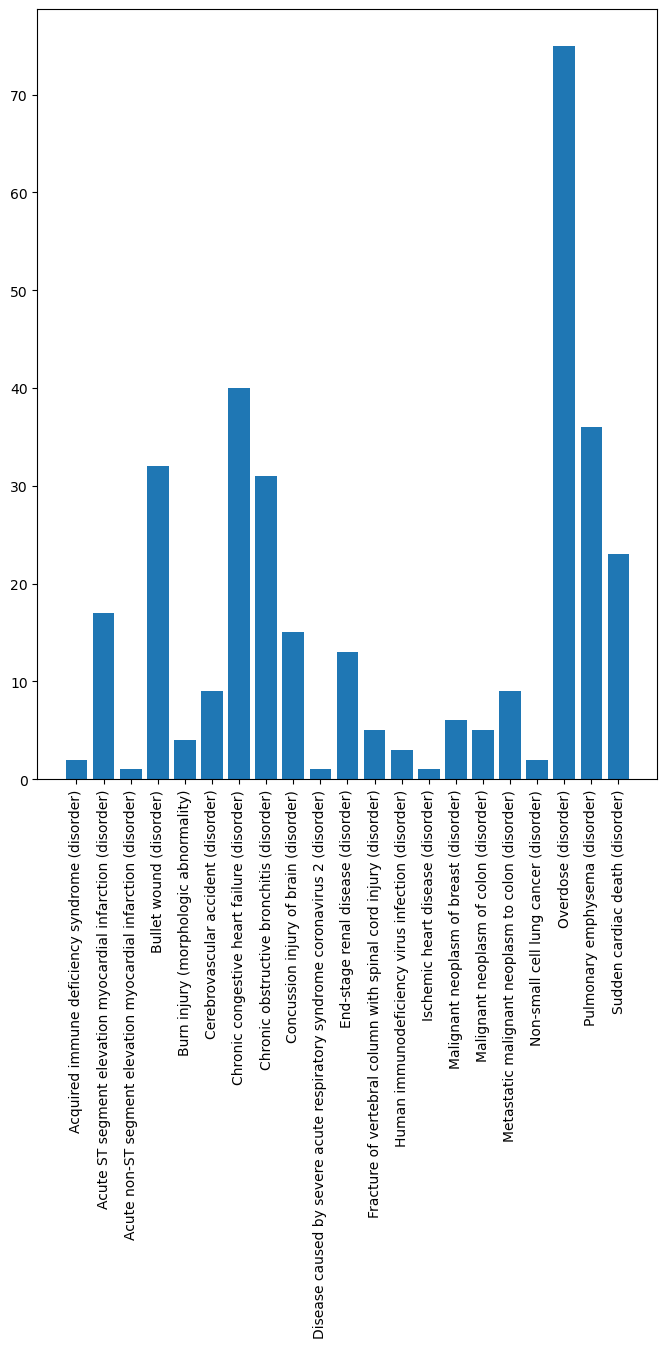

In [31]:
plot_dat = Maternal_Deaths.groupby('CAUSE_OF_DEATH').agg(freq = pd.NamedAgg(column="CAUSE_OF_DEATH", aggfunc="count"))
import matplotlib.pyplot as plt
plt.figure(figsize=(8,10))
plt.bar(plot_dat.index, plot_dat['freq'])
plt.xticks(rotation=90)

# Preprocess Data

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
numeric_cols = ['INCOME', 'RELATIVE_EXPENSES', 'DIASTOLIC_BP', 'SYSTOLIC_BP', "HEART_RATE", "RESPIRATORY_RATE", "PLATELETS", "HEMOGLOBIN"]
categorical_cols = ['INTENSE_PARTNER_FEAR', 'TRANSPORTATION_BARRIER', 'HOUSING_INSECURITY']
all_cols = ['INCOME', 'RELATIVE_EXPENSES', 'DIASTOLIC_BP', 'SYSTOLIC_BP', "HEART_RATE", "RESPIRATORY_RATE", "PLATELETS", "HEMOGLOBIN", "INTENSE_PARTNER_FEAR", "TRANSPORTATION_BARRIER", "HOUSING_INSECURITY", 'Maternal_Mortality']
final_data = LAfemMed[all_cols].dropna()
final_data['INTENSE_PARTNER_FEAR'] = final_data['INTENSE_PARTNER_FEAR'].map({'Yes': 1, 'No': 0})
print(final_data['INTENSE_PARTNER_FEAR'].isna().sum())
final_data['TRANSPORTATION_BARRIER'] = np.where(final_data['TRANSPORTATION_BARRIER'].isin(['Yes  it has kept me from non-medical meetings  appointments  work  or from getting things that I need', 'Yes  it has kept me from medical appointments or from getting my medications']), 1, 0)
print(final_data['TRANSPORTATION_BARRIER'].isna().sum())
final_data['HOUSING_INSECURITY'] = final_data['HOUSING_INSECURITY'].map({'Yes': 1, 'No': 0, 'I choose not to answer this question': 0})
print(final_data['HOUSING_INSECURITY'].isna().sum())
scale = StandardScaler()
X = np.column_stack([scale.fit_transform(final_data[numeric_cols]), final_data[categorical_cols]])
y = final_data['Maternal_Mortality'].to_numpy().astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

0
0
0


In [11]:
from sklearn.naive_bayes import GaussianNB
GNB = GaussianNB()
GNB.fit(X_train, y_train)
GNB_preds = GNB.predict(X_test)

In [12]:
from LogisticRegression import LR_class
LR = LR_class()
LR_fit = LR.LogRes(X_train,y_train)
LR_preds = LR_fit.predict(X_test)

In [13]:
from SVM import SVM_class
svm = SVM_class(X_train, y_train)
svm.best_fit()
svm_preds = svm.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


In [14]:
import RandForest
rf = RandForest.RF_hyperparams(X_train, y_train)
rf.best_fit()
rf_preds =rf.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [15]:
from NNmod import NN_CVmod, NN_PredMod
in_size = X_train.shape[1]
HidLay_combos = [[2], [6, 3], [10, 5, 2]]
for combo in HidLay_combos:
    nn_mort = NN_CVmod(input_size=in_size, hidden_layers=combo, epochs=1000)
    train_loss, valid_loss = nn_mort.NN_CV(X_train, y_train, k=5)
    print(f"Hidden Layers: {combo} | Average Train Loss: {train_loss:.4f} | Average Valid Loss: {valid_loss:.4f}")
nn_mort = NN_PredMod(input_size=in_size, hidden_layers=[6, 3], epochs=1000)
nn_mort.fit(X_train, y_train)
nn_Spreds = nn_mort.predict(X_test)

Fold: 1 of 5
Fold: 2 of 5
Fold: 3 of 5
Fold: 4 of 5
Fold: 5 of 5
Hidden Layers: [2] | Average Train Loss: 0.1400 | Average Valid Loss: 0.1398
Fold: 1 of 5
Fold: 2 of 5
Fold: 3 of 5
Fold: 4 of 5
Fold: 5 of 5
Hidden Layers: [6, 3] | Average Train Loss: 0.0624 | Average Valid Loss: 0.0630
Fold: 1 of 5
Fold: 2 of 5
Fold: 3 of 5
Fold: 4 of 5
Fold: 5 of 5
Hidden Layers: [10, 5, 2] | Average Train Loss: 0.2151 | Average Valid Loss: 0.2170


In [16]:
from XGBoost import XGBclass
import xgboost as xgb
xgbcv = XGBclass(X, y)
best_params = xgbcv.xgb_Kfold(k=5)
best_params
xgb_mod = xgb.XGBClassifier(**best_params)
xgb_mod.fit(X_train, y_train)
xgb_preds = xgb_mod.predict(X_test)

  7%|▋         | 37/500 [01:22<17:12,  2.23s/trial, best loss: 0.060367617104343685]


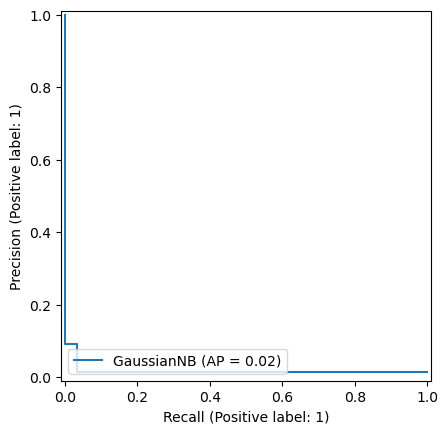

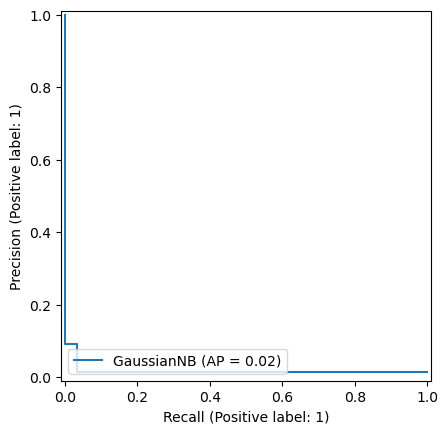

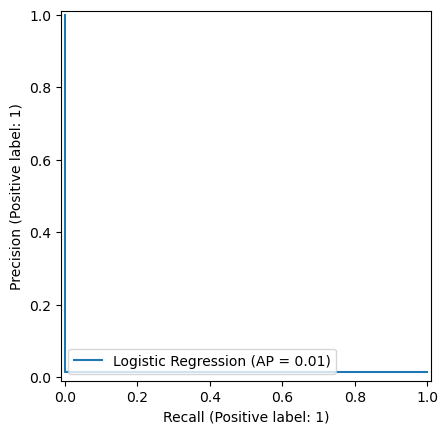

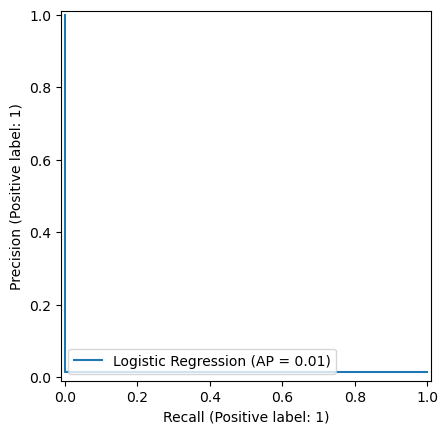

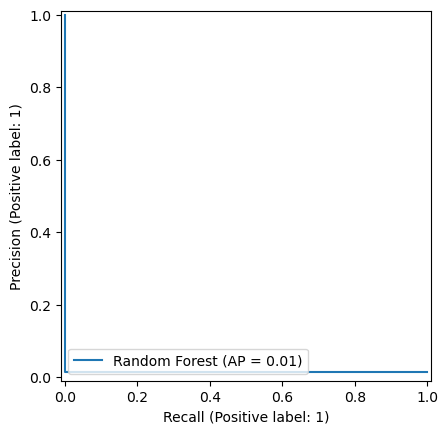

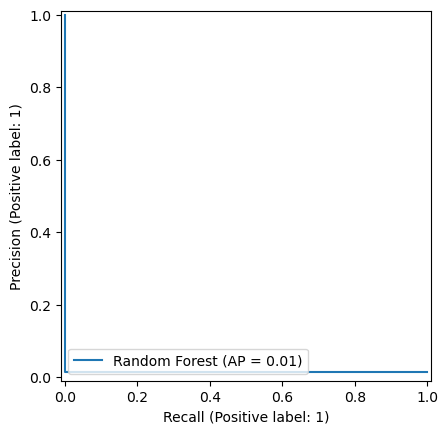

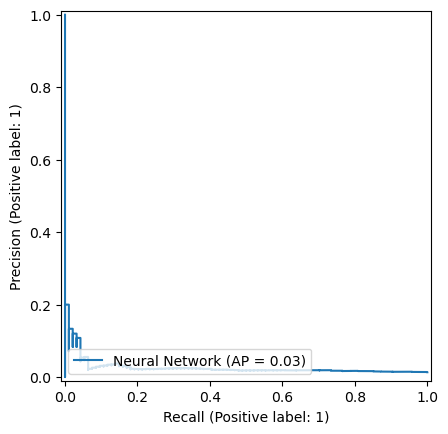

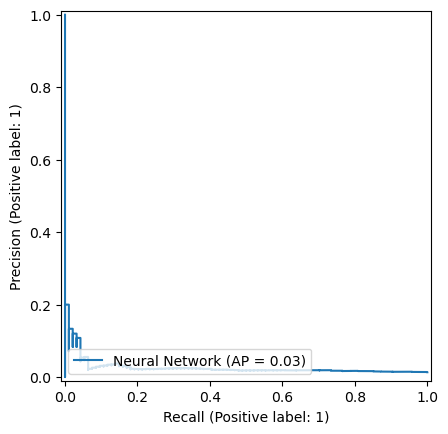

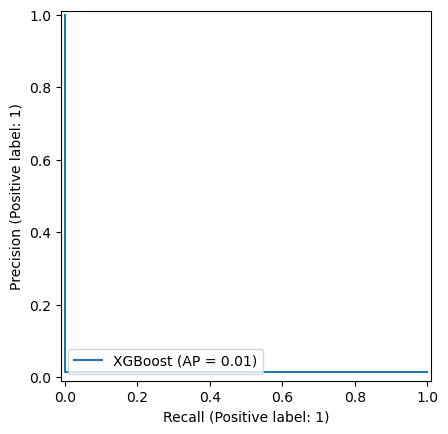

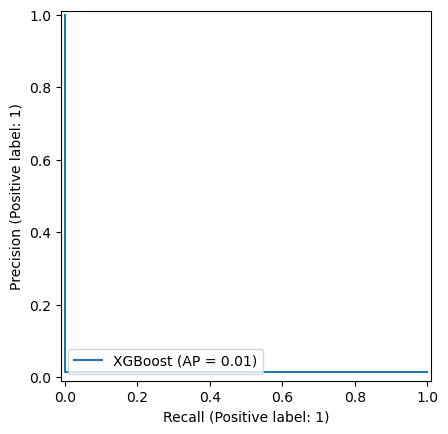

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, PrecisionRecallDisplay
GNB_PRcurve = PrecisionRecallDisplay.from_predictions(y_test, GNB_preds, name="GaussianNB")
GNB_PRcurve.plot()
LR_PRcurve = PrecisionRecallDisplay.from_predictions(y_test, LR_preds, name="Logistic Regression")
LR_PRcurve.plot()
RF_PRcurve = PrecisionRecallDisplay.from_predictions(y_test, rf_preds, name="Random Forest")
RF_PRcurve.plot()
NN_PRcurve = PrecisionRecallDisplay.from_predictions(y_test, nn_Spreds, name="Neural Network")
NN_PRcurve.plot()
XGB_PRcurve = PrecisionRecallDisplay.from_predictions(y_test, xgb_preds, name="XGBoost")
XGB_PRcurve.plot()